In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [8]:
datos = load_breast_cancer(as_frame=True)
df = datos.frame
x = df['mean radius']
mu = x.mean()
mu

np.float64(14.127291739894552)

In [9]:
# np.random.seed(123)
tamaños = [10,30,50,100,200,500]
muestras =[]
estimadores=[]
errores = []

for n in tamaños:
    muestra = x.sample(n=n, replace=True)
    estimador = muestra.mean()
    error = abs(estimador-mu)
    muestras.append(n)
    estimadores.append(estimador)
    errores.append(error)

pd.DataFrame({'muestras':muestras, 'estimadores': estimadores, 'errores':errores})

,muestras,estimadores,errores
0,10,14.295000,0.167708
1,30,13.903267,0.224025
2,50,14.060000,0.067292
3,100,14.113630,0.013662
4,200,13.906085,0.221207
5,500,13.798254,0.329038


In [15]:
tamaños_1 = [10,30,50,100,200,500, 1000, 10000, 100000]
B =1000
epsilon = 0.05
resultados=[]

for n in tamaños_1:
    errores = []
    for i in range(B):
        muestra = x.sample(n=n, replace=True)
        estimador = muestra.mean()

        error = abs(estimador - mu)
        errores.append(error)

    probabilidad = np.mean(np.array(errores) > epsilon)

    resultados.append([n,probabilidad])

resultado = pd.DataFrame(resultados, columns=['n', 'P(error>epsilon)'])
resultado

,n,P(error>epsilon)
0,10,0.970
1,30,0.932
2,50,0.926
3,100,0.880
4,200,0.833
5,500,0.748
6,1000,0.650
7,10000,0.141
8,100000,0.000


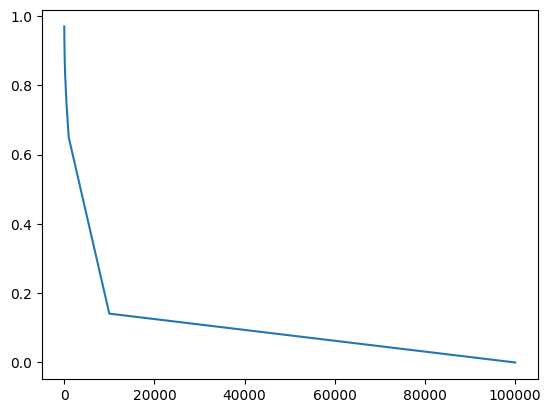

In [16]:
import matplotlib.pyplot as plt

plt.plot(resultado['n'], resultado['P(error>epsilon)'])
